# EDA on Base Features

This notebook performs EDA on the base features as requested, including:
- Distribution analysis
- Correlation with target and between features
- Anomaly/Outlier detection and mapping to timeframes (e.g., 2022 Ukraine war beginning)
- Custom backward imputation for outlier handling


## 1. Load Data

We load data from 2021-01-01 to 2024-12-31 to have enough data for the backward imputation (seasonal period of the previous year).


In [4]:
# Set the primary column for outlier analysis (e.g., spot price)
col_focus = 'spot_price_act_lag_24_hours'

target = "prod_act_sum"

base_features = [
    "prod_act_sum_lag_72_hours",
    "missing_pinst_sum_lag_42_hours",
    "spot_price_act_lag_42_hours",
    "rebap_price_est_lag_42_hours",
    "fcr_price_act_lag_42_hours",
    "afrr_neg_avg_price_act_lag_42_hours",
    "afrr_pos_avg_price_act_lag_42_hours",
    "prod_fc_sum_lag_0_hours",
    "temperature_fc_lag_0_hours",
    "solar_fc_lag_0_hours",
    "wind_fc_lag_0_hours"
]

In [5]:
import sys
from pathlib import Path
import pandas as pd

# Add the parent directory to sys.path to import generate_dummy_data
sys.path.append(str(Path.cwd().parent))
from generate_dummy_data import generate_dummy_training_data

training_data = generate_dummy_training_data()


## 2. Distribution Analysis

Looking at the distribution of all variables.


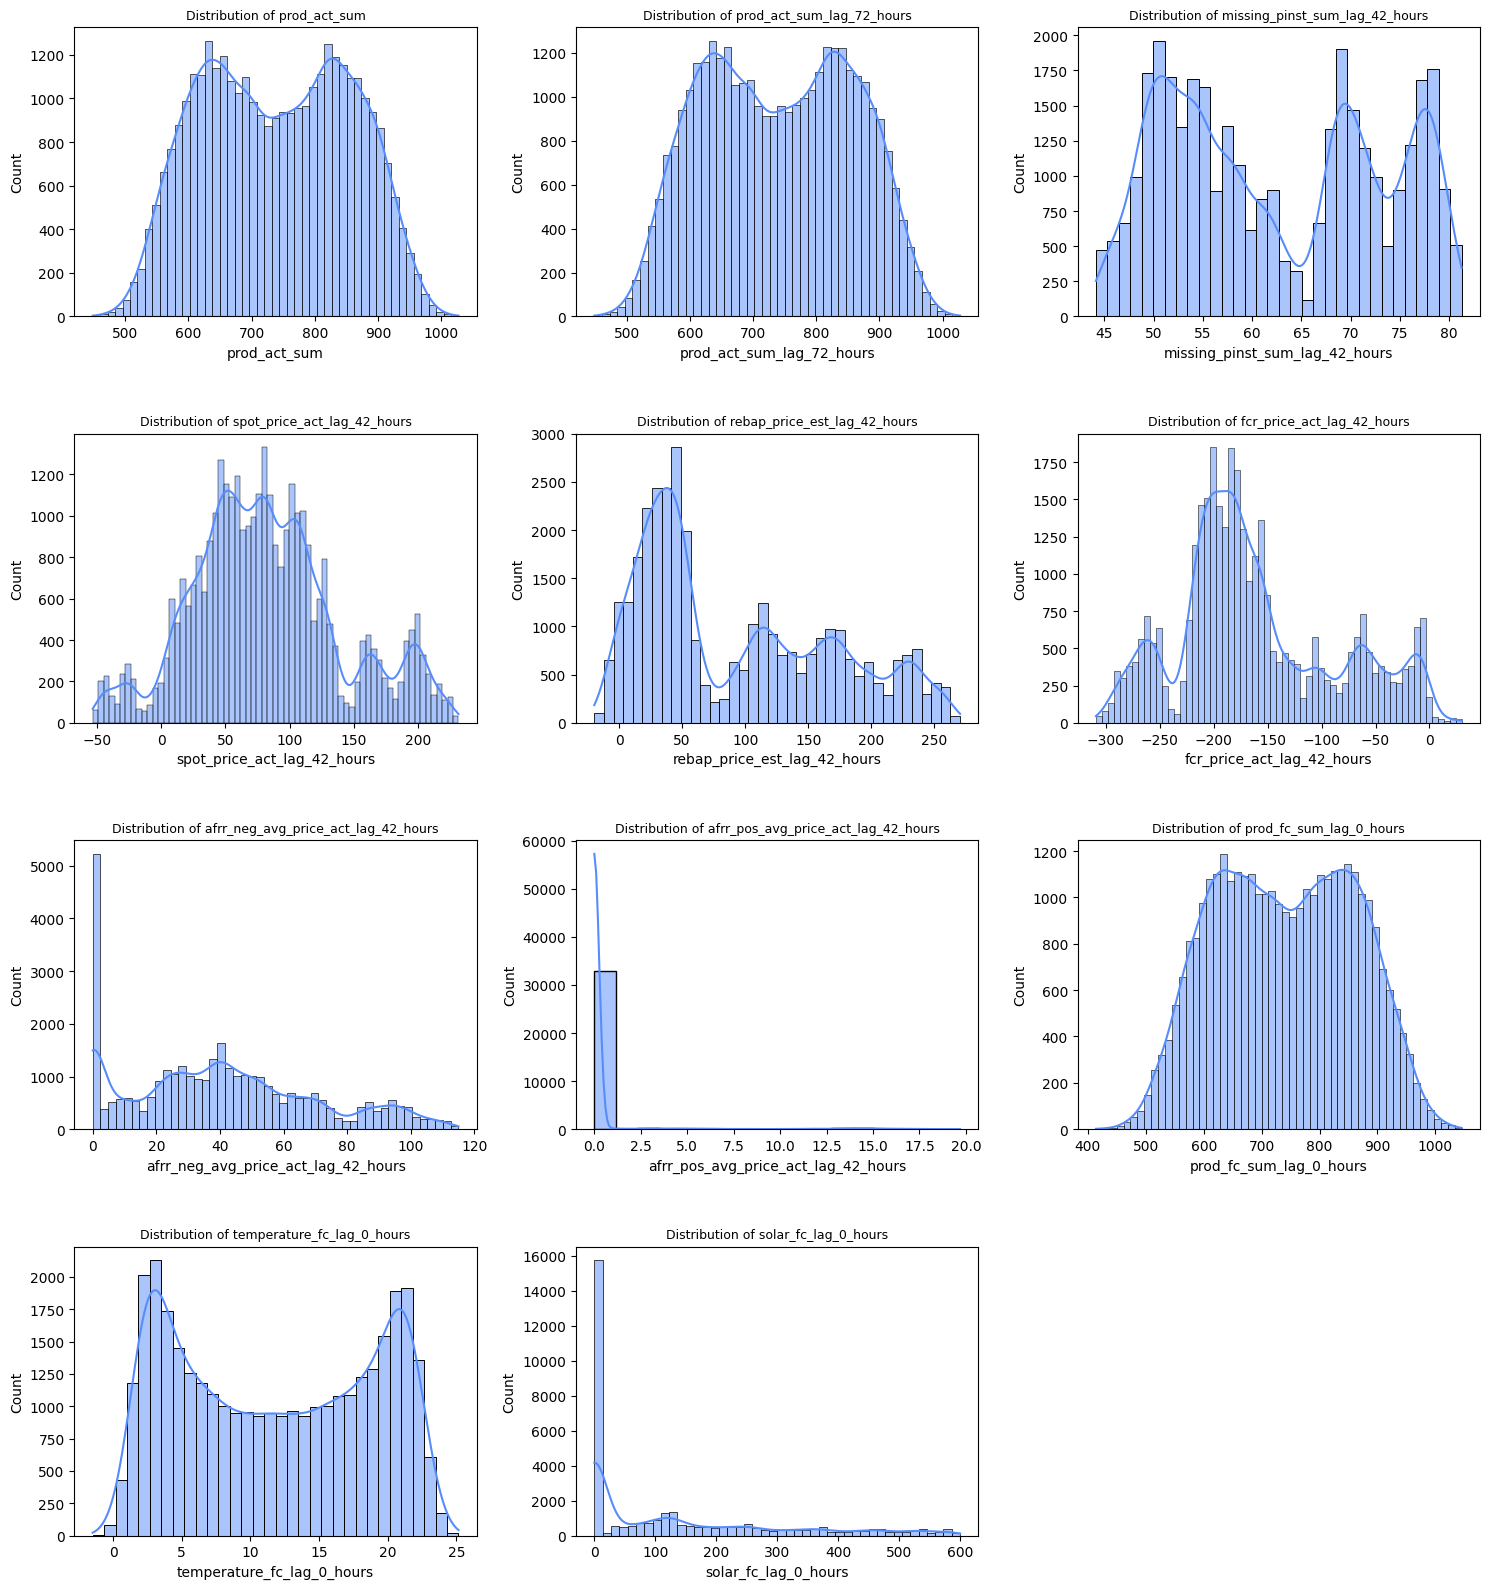

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
cols_to_plot = [target] + base_features
n_cols = 3
n_rows = (len(cols_to_plot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    if col in training_data.columns:
        sns.histplot(training_data[col], kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}', fontsize=9)
    else:
        axes[i].set_visible(False)

plt.tight_layout(h_pad=4.0)
plt.savefig('figures/distribution_analysis.png')
plt.show()


### 2.1 Wind Forecast Transformation Analysis

Comparing the original wind forecast with its logarithmic transformation.


In [7]:
import numpy as np

if "wind_fc_lag_0_hours" in training_data.columns:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Original wind_fc
    sns.histplot(training_data["wind_fc_lag_0_hours"], kde=True, ax=axes[0])
    axes[0].set_title('Distribution of wind_fc')
    
    # Log transformed wind_fc
    # Using log1p to handle zeros correctly
    sns.histplot(np.log1p(training_data["wind_fc_lag_0_hours"]), kde=True, ax=axes[1])
    axes[1].set_title('Distribution of log(wind_fc + 1)')
    
    plt.tight_layout()
    plt.savefig('figures_interpretation/wind_fc_transformation.png')
    plt.show()


## 3. Correlation Analysis

### 3.1 Correlation Matrix


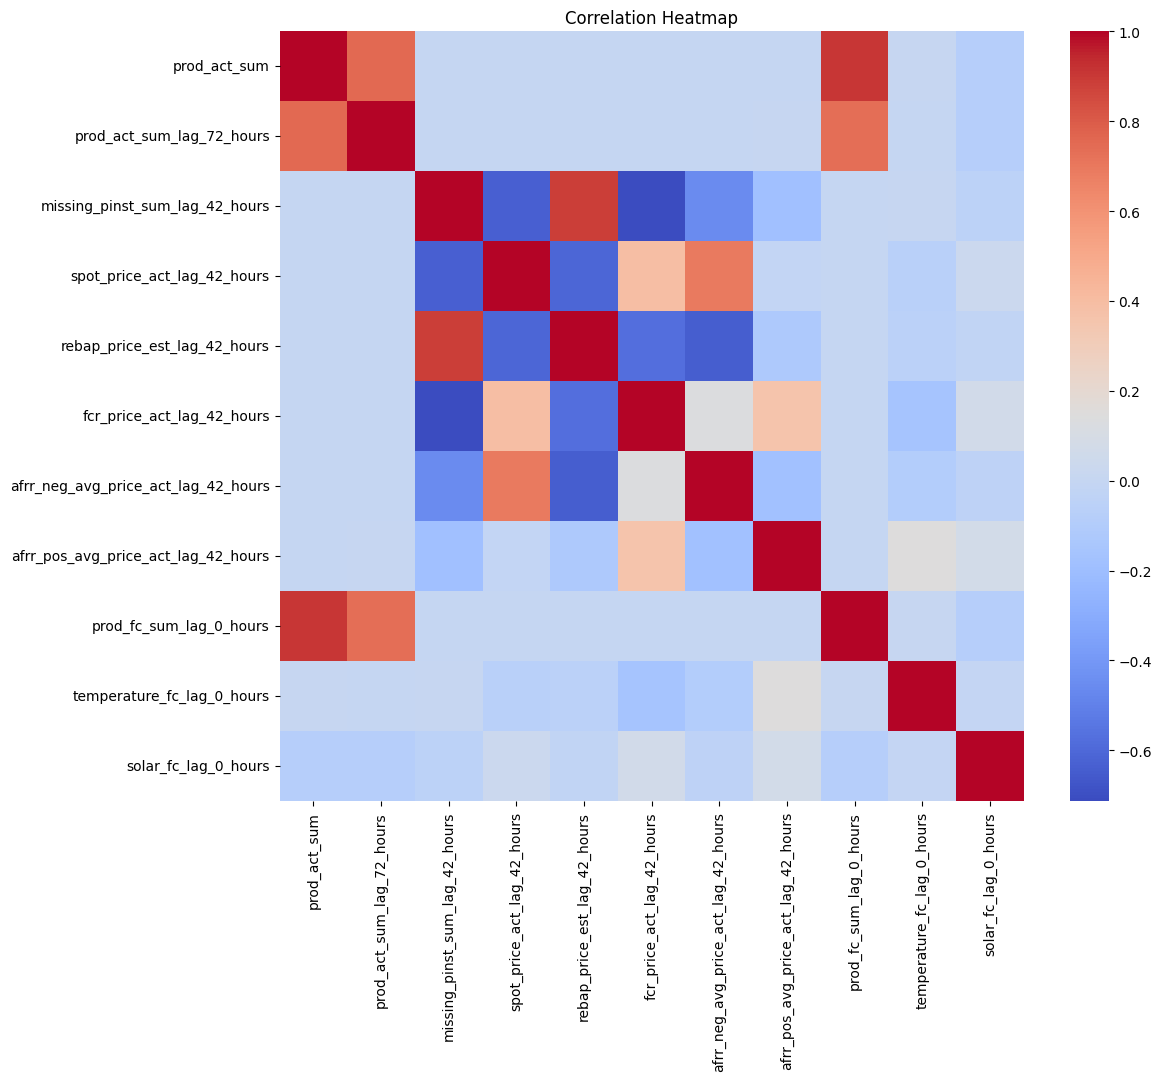

In [9]:
plt.figure(figsize=(12, 10))
corr_cols = [c for c in [target] + base_features if c in training_data.columns]
corr = training_data[corr_cols].corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.savefig('figures/correlation_heatmap.png', bbox_inches='tight')
plt.show()


### 3.2 Correlation with Target


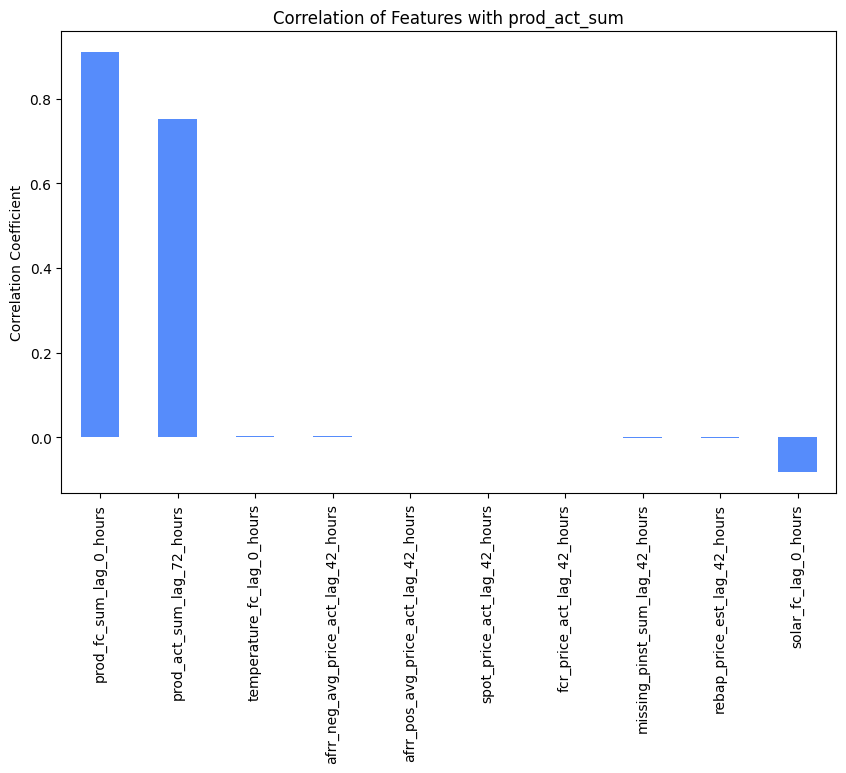

In [10]:
target_corr = corr[target].sort_values(ascending=False)
plt.figure(figsize=(10, 6))
target_corr.drop(target).plot(kind='bar')
plt.title(f"Correlation of Features with {target}")
plt.ylabel("Correlation Coefficient")
plt.savefig('figures/correlation_with_target.png', bbox_inches='tight')
plt.show()


## 4. Anomaly / Outlier Detection

We use Z-score detection and map the anomalies to time frames, focusing on the beginning of the Ukraine war in early 2022.


In [13]:
import scipy.stats as stats
def detect_outliers_zscore(series, threshold=3):
    z_scores = np.abs(stats.zscore(series.dropna()))
    outliers = pd.Series(False, index=series.index)
    outliers.loc[series.dropna().index] = z_scores > threshold
    return outliers
df=training_data
outlier_summary = {}
for col in base_features:
    if col in df.columns:
        outliers = detect_outliers_zscore(df[col])
        outlier_summary[col] = outliers.sum()
        
        if outliers.sum() > 0:
            print(f"{col}: {outliers.sum()} outliers detected")

# Focusing on Spot Price as it was highly volatile in 2022
if col_focus in df.columns:
    df['is_outlier'] = detect_outliers_zscore(df[col_focus])
    
    plt.figure(figsize=(15, 6))
    plt.plot(df.index, df[col_focus], label='Actual Value', color='blue', alpha=0.6)
    plt.scatter(df[df['is_outlier']].index, df[df['is_outlier']][col_focus], 
                color='red', label='Outliers', s=10)
    
    # Mark Ukraine war beginning (approx Feb 24, 2022)
    ukraine_war = pd.Timestamp("2022-02-24", tz="CET")
    plt.axvline(ukraine_war, color='black', linestyle='--', label='Ukraine War Start')
    
    plt.title(f"Outliers in {col_focus}")
    plt.legend()
    plt.savefig('figures_interpretation/outlier_detection.png')
    plt.show()


afrr_pos_avg_price_act_lag_42_hours: 809 outliers detected


## 5. Outlier Handling (Backward Imputation)

As requested, we apply the backward imputation: 
- 60% from same seasonal period of previous year
- 40% from the original value


In [14]:
from exploration.eda_utils import handle_outliers_backward_imputation

if col_focus in df.columns:
    df[f'{col_focus}_corrected'] = handle_outliers_backward_imputation(df, col_focus, df['is_outlier'])
    
    # Visualize comparison for a specific window in 2022
    window_start = pd.Timestamp("2022-02-01", tz="CET")
    window_end = pd.Timestamp("2025-04-01", tz="CET")
    
    plot_df = df.loc[window_start:window_end]
    
    plt.figure(figsize=(15, 6))
    plt.plot(plot_df.index, plot_df[col_focus], label='Original (with outliers)', color='red', alpha=0.5, linewidth=2)
    plt.plot(plot_df.index, plot_df[f'{col_focus}_corrected'], label='Corrected (Backward Imputation)', color='green', linewidth=1)
    
    plt.title(f"Outlier Correction Comparison for {col_focus}")
    plt.legend()
    plt.savefig('figures_interpretation/outlier_correction_comparison.png')
    plt.show()


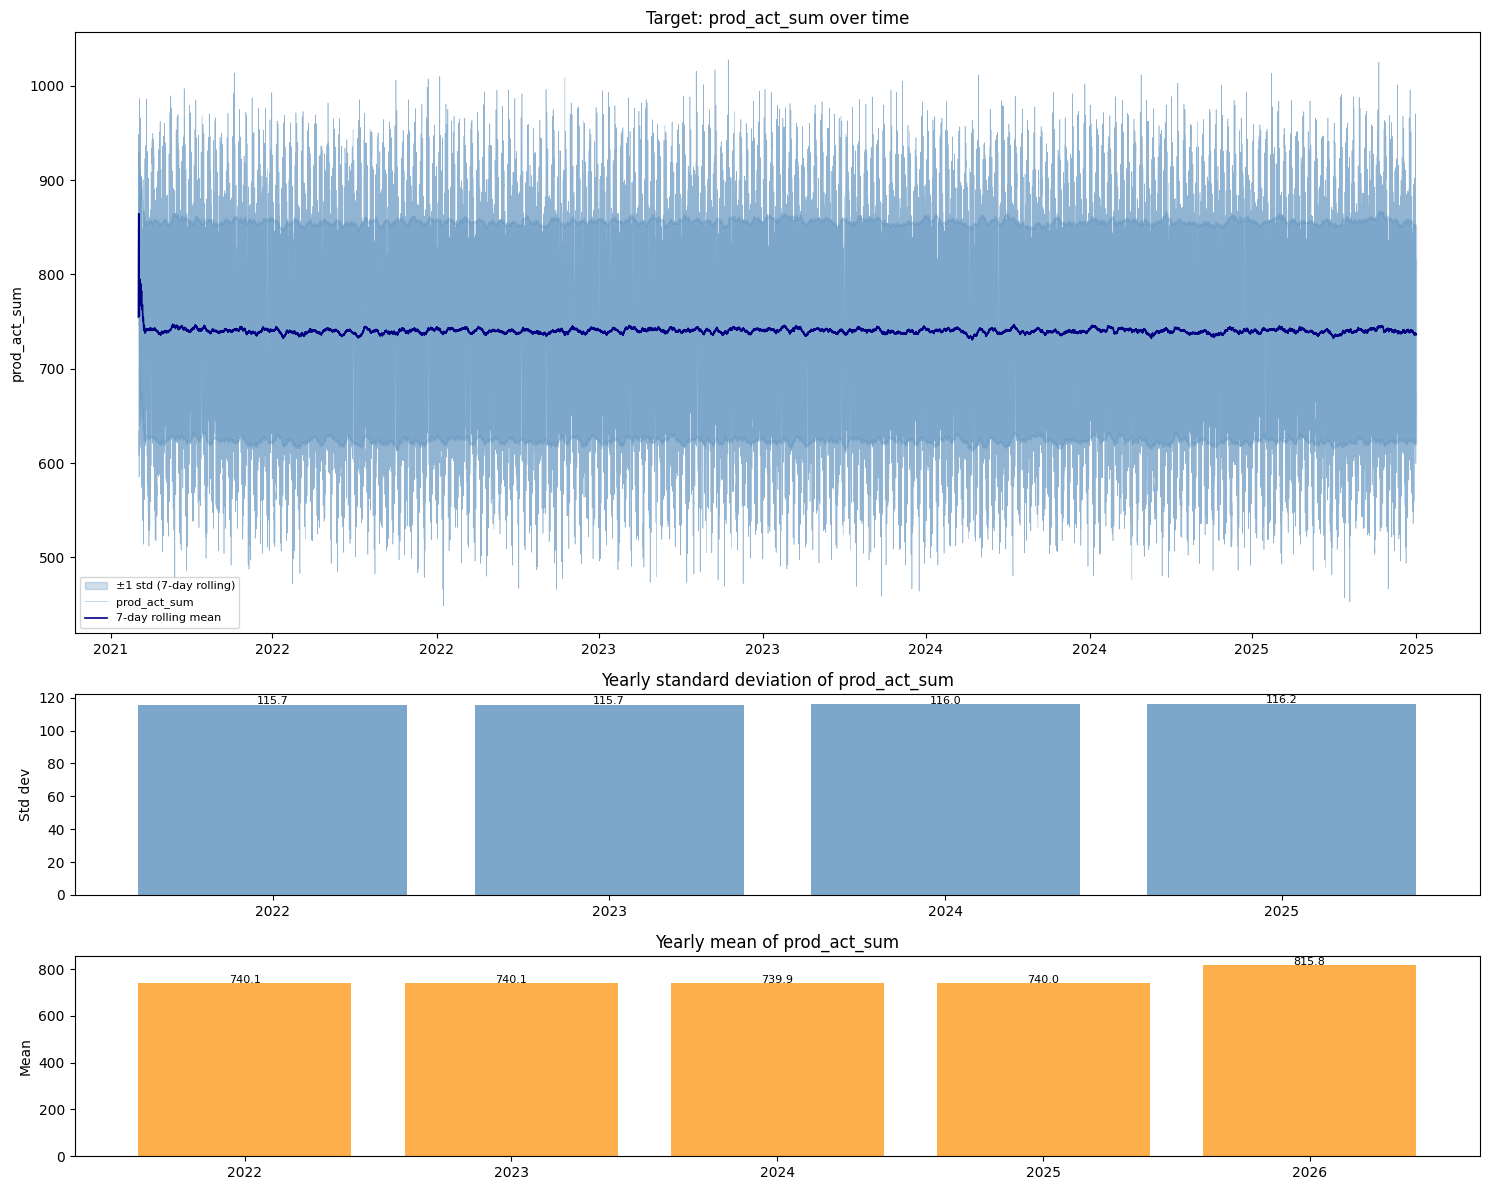


Yearly statistics:
                             mean     std  cv (std/mean)
2022-12-31 00:00:00+01:00  740.12  115.71           0.16
2023-12-31 00:00:00+01:00  740.08  115.71           0.16
2024-12-31 00:00:00+01:00  739.91  115.98           0.16
2025-12-31 00:00:00+01:00  739.97  116.17           0.16
2026-12-31 00:00:00+01:00  815.84     NaN            NaN


In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import os
import pandas as pd

series = df["prod_act_sum"].dropna()
yearly = series.resample("YE")
yearly_std = yearly.std()
yearly_mean = yearly.mean()

fig, axes = plt.subplots(3, 1, figsize=(15, 12), gridspec_kw={"height_ratios": [3, 1, 1]})

# ── top: raw series + rolling std band ──────────────────────────────────────
roll_mean = series.rolling("7D").mean()
roll_std  = series.rolling("7D").std()

axes[0].fill_between(series.index,
                     roll_mean - roll_std, roll_mean + roll_std,
                     alpha=0.25, color="steelblue", label="±1 std (7-day rolling)")
axes[0].plot(series.index, series, lw=0.4, color="steelblue", alpha=0.6, label="prod_act_sum")
axes[0].plot(roll_mean.index, roll_mean, lw=1.2, color="navy", label="7-day rolling mean")
axes[0].set_ylabel("prod_act_sum")
axes[0].legend(fontsize=8)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].set_title("Target: prod_act_sum over time")

# ── middle: yearly std bar ───────────────────────────────────────────────────
years = [str(t.year) for t in yearly_std.index]
axes[1].bar(years, yearly_std.values, color="steelblue", alpha=0.7)
axes[1].set_ylabel("Std dev")
axes[1].set_title("Yearly standard deviation of prod_act_sum")
for i, (y, v) in enumerate(zip(years, yearly_std.values)):
    axes[1].text(i, v + 0.5, f"{v:.1f}", ha="center", fontsize=8)

# ── bottom: yearly mean bar ──────────────────────────────────────────────────
axes[2].bar(years, yearly_mean.values, color="darkorange", alpha=0.7)
axes[2].set_ylabel("Mean")
axes[2].set_title("Yearly mean of prod_act_sum")
for i, (y, v) in enumerate(zip(years, yearly_mean.values)):
    axes[2].text(i, v + 0.5, f"{v:.1f}", ha="center", fontsize=8)

plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/target_prod_act_sum.png", bbox_inches="tight")
plt.show()

print("\nYearly statistics:")
print(pd.DataFrame({"mean": yearly_mean, "std": yearly_std, "cv (std/mean)": yearly_std / yearly_mean}).round(2))
